In [1]:
# Copyright (c) MONAI Consortium
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#     http://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Denoising Diffusion Probabilistic Models with MedNIST Dataset

This tutorial illustrates how to use MONAI for training a denoising diffusion probabilistic model (DDPM)[1] to create
synthetic 2D images.

[1] - Ho et al. "Denoising Diffusion Probabilistic Models" https://arxiv.org/abs/2006.11239


## Setup environment

In [1]:
!python -c "import monai" || pip install -q "monai-weekly[tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

In [2]:
!pip install lpips

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python -m pip install --upgrade pip


## Setup imports

In [3]:
import os
import shutil
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from monai import transforms
from monai.apps import MedNISTDataset
from monai.config import print_config
from monai.data import CacheDataset, DataLoader
from monai.utils import first, set_determinism
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

from generative.inferers import DiffusionInferer
from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler

from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import lpips

print_config()

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MONAI version: 1.4.0
Numpy version: 1.24.4
Pytorch version: 2.1.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 46a5272196a6c2590ca2589029eed8e4d56ff008
MONAI __file__: /home/<username>/.local/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: 0.24.0
scipy version: 1.14.0
Pillow version: 10.4.0
Tensorboard version: 2.16.2
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.16.1+cu121
tqdm version: 4.66.5
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 6.0.0
pandas version: 2.2.2
einops version: 0.8.0
transformers version: 4.44.2
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing th

## Setup data directory

You can specify a directory with the MONAI_DATA_DIRECTORY environment variable.

This allows you to save results and reuse downloads.

If not specified a temporary directory will be used.

In [4]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmp_oy4q6xt


## Set deterministic training for reproducibility

In [5]:
set_determinism(42)

## Setup MedNIST Dataset and training and validation dataloaders
In this tutorial, we will train our models on the MedNIST dataset available on MONAI
(https://docs.monai.io/en/stable/apps.html#monai.apps.MedNISTDataset). In order to train faster, we will select just
one of the available classes ("Hand"), resulting in a training set with 7999 2D images.

In [6]:
train_data = MedNISTDataset(root_dir=root_dir, section="training", download=True, progress=False, seed=0)
train_datalist = [{"image": item["image"]} for item in train_data.data if item["class_name"] == "Hand"]

2024-12-18 12:27:41,861 - INFO - Downloaded: /tmp/tmp_oy4q6xt/MedNIST.tar.gz
2024-12-18 12:27:41,959 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2024-12-18 12:27:41,960 - INFO - Writing into directory: /tmp/tmp_oy4q6xt.


Here we use transforms to augment the training dataset:

1. `LoadImaged` loads the hands images from files.
1. `EnsureChannelFirstd` ensures the original data to construct "channel first" shape.
1. `ScaleIntensityRanged` extracts intensity range [0, 255] and scales to [0, 1].
1. `RandAffined` efficiently performs rotate, scale, shear, translate, etc. together based on PyTorch affine transform.

In [7]:
train_transforms = transforms.Compose(
    [
        transforms.LoadImaged(keys=["image"]),
        transforms.EnsureChannelFirstd(keys=["image"]),
        transforms.ScaleIntensityRanged(keys=["image"], a_min=0.0, a_max=255.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.RandAffined(
            keys=["image"],
            rotate_range=[(-np.pi / 36, np.pi / 36), (-np.pi / 36, np.pi / 36)],
            translate_range=[(-1, 1), (-1, 1)],
            scale_range=[(-0.05, 0.05), (-0.05, 0.05)],
            spatial_size=[64, 64],
            padding_mode="zeros",
            prob=0.5,
        ),
    ]
)
train_ds = CacheDataset(data=train_datalist, transform=train_transforms)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=4, persistent_workers=True)

Loading dataset: 100%|██████████| 7999/7999 [00:06<00:00, 1197.72it/s]


In [8]:
val_data = MedNISTDataset(root_dir=root_dir, section="validation", download=True, progress=False, seed=0)
val_datalist = [{"image": item["image"]} for item in val_data.data if item["class_name"] == "Hand"]
val_transforms = transforms.Compose(
    [
        transforms.LoadImaged(keys=["image"]),
        transforms.EnsureChannelFirstd(keys=["image"]),
        transforms.ScaleIntensityRanged(keys=["image"], a_min=0.0, a_max=255.0, b_min=0.0, b_max=1.0, clip=True),
    ]
)
val_ds = CacheDataset(data=val_datalist, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=4, persistent_workers=True)

2024-12-18 12:28:15,681 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2024-12-18 12:28:15,682 - INFO - File exists: /tmp/tmp_oy4q6xt/MedNIST.tar.gz, skipped downloading.
2024-12-18 12:28:15,683 - INFO - Non-empty folder exists in /tmp/tmp_oy4q6xt/MedNIST, skipped extracting.


Loading dataset: 100%|██████████| 1005/1005 [00:00<00:00, 1211.40it/s]


### Visualisation of the training images

batch shape: torch.Size([128, 1, 64, 64])


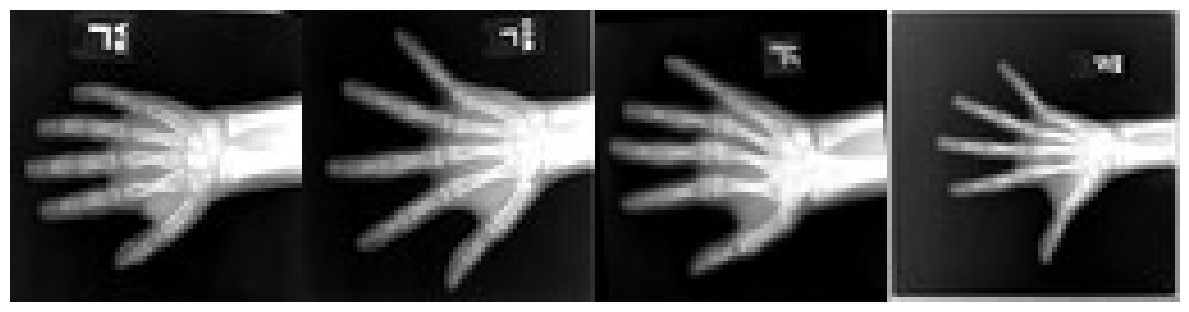

In [9]:
check_data = first(train_loader)
print(f"batch shape: {check_data['image'].shape}")
image_visualisation = torch.cat(
    [check_data["image"][0, 0], check_data["image"][1, 0], check_data["image"][2, 0], check_data["image"][3, 0]], dim=1
)
plt.figure("training images", (12, 6))
plt.imshow(image_visualisation, vmin=0, vmax=1, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

### Define network, scheduler, optimizer, and inferer
At this step, we instantiate the MONAI components to create a DDPM, the UNET, the noise scheduler, and the inferer used for training and sampling. We are using
the original DDPM scheduler containing 1000 timesteps in its Markov chain, and a 2D UNET with attention mechanisms
in the 2nd and 3rd levels, each with 1 attention head.

In [10]:
device = torch.device("cuda")

model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    num_channels=(128, 256, 256),
    attention_levels=(False, True, True),
    num_res_blocks=1,
    num_head_channels=256,
)
model.to(device)

scheduler = DDPMScheduler(num_train_timesteps=1000)

optimizer = torch.optim.Adam(params=model.parameters(), lr=2.5e-5)

inferer = DiffusionInferer(scheduler)

### Model training
Here, we are training our model for 75 epochs (training time: ~50 minutes).

If you would like to skip the training and use a pre-trained model instead, set `use_pretrained=True`. This model was trained using the code in `tutorials/generative/distributed_training/ddpm_training_ddp.py`

100%|██████████| 1000/1000 [00:10<00:00, 92.67it/s]


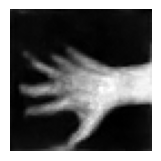

100%|██████████| 1000/1000 [00:10<00:00, 93.41it/s]


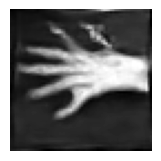

100%|██████████| 1000/1000 [00:10<00:00, 93.57it/s]


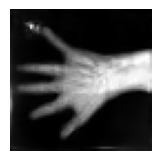

100%|██████████| 1000/1000 [00:10<00:00, 92.34it/s]


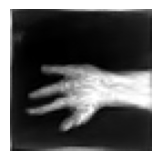

train completed, total time: 603.5048861503601.


In [11]:
use_pretrained = False

if use_pretrained:
    model = torch.hub.load("marksgraham/pretrained_generative_models:v0.2", model="ddpm_2d", verbose=True).to(device)
else:
    n_epochs = 20
    val_interval = 5
    epoch_loss_list = []
    val_epoch_loss_list = []

    scaler = GradScaler()
    total_start = time.time()
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=70)
        progress_bar.set_description(f"Epoch {epoch}")
        for step, batch in progress_bar:
            images = batch["image"].to(device)
            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=True):
                # Generate random noise
                noise = torch.randn_like(images).to(device)

                # Create timesteps
                timesteps = torch.randint(
                    0, inferer.scheduler.num_train_timesteps, (images.shape[0],), device=images.device
                ).long()

                # Get model prediction
                noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)

                loss = F.mse_loss(noise_pred.float(), noise.float())

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

            progress_bar.set_postfix({"loss": epoch_loss / (step + 1)})
        epoch_loss_list.append(epoch_loss / (step + 1))

        if (epoch + 1) % val_interval == 0:
            model.eval()
            val_epoch_loss = 0
            for step, batch in enumerate(val_loader):
                images = batch["image"].to(device)
                with torch.no_grad():
                    with autocast(enabled=True):
                        noise = torch.randn_like(images).to(device)
                        timesteps = torch.randint(
                            0, inferer.scheduler.num_train_timesteps, (images.shape[0],), device=images.device
                        ).long()
                        noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)
                        val_loss = F.mse_loss(noise_pred.float(), noise.float())

                val_epoch_loss += val_loss.item()
                progress_bar.set_postfix({"val_loss": val_epoch_loss / (step + 1)})
            val_epoch_loss_list.append(val_epoch_loss / (step + 1))

            # Sampling image during training
            noise = torch.randn((1, 1, 64, 64))
            noise = noise.to(device)
            scheduler.set_timesteps(num_inference_steps=1000)
            with autocast(enabled=True):
                image = inferer.sample(input_noise=noise, diffusion_model=model, scheduler=scheduler)

            plt.figure(figsize=(2, 2))
            plt.imshow(image[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
            plt.tight_layout()
            plt.axis("off")
            plt.show()

    total_time = time.time() - total_start
    print(f"train completed, total time: {total_time}.")

In [29]:
# save current model (backup, no need to train again)
torch.save(model.state_dict(), "epoch_20.pth")

In [11]:
# load checkpoint (only train once)
model.load_state_dict(torch.load("epoch_20.pth", weights_only=True))

/home/u8518646/.local/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


<All keys matched successfully>

### Plotting sampling process along DDPM's Markov chain

100%|██████████| 1000/1000 [00:14<00:00, 69.34it/s]


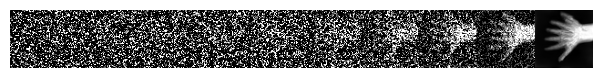

In [13]:
model.eval()
noise = torch.randn((1, 1, 64, 64))
noise = noise.to(device)
scheduler.set_timesteps(num_inference_steps=1000)
with autocast(enabled=True):
    image, intermediates = inferer.sample(
        input_noise=noise, diffusion_model=model, scheduler=scheduler, save_intermediates=True, intermediate_steps=100
    )

chain = torch.cat(intermediates, dim=-1)

plt.style.use("default")
plt.imshow(chain[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()

In [14]:
## self-defined sample function
def backward_process(model, noise):
    with torch.no_grad():
        x = noise
        for t in range(1000-1, -1, -1):
            t_tensor = torch.full((1,), t, device=device, dtype=torch.float32)
            noise_pred = model(x, timesteps=t_tensor)
            
            # x = sqrt_recip_alphas[t] * (x - betas[t] * noise_pred / sqrt_one_minus_alphas_bar[t])
            # if t > 0:
            #     x = x + sigmas[t] * torch.randn_like(x)
            x, _ = scheduler.step(noise_pred, t, x)

        plt.imshow(x.detach().cpu().numpy().squeeze(), cmap="gray")
        plt.tight_layout()
        plt.axis("off")
        plt.show()

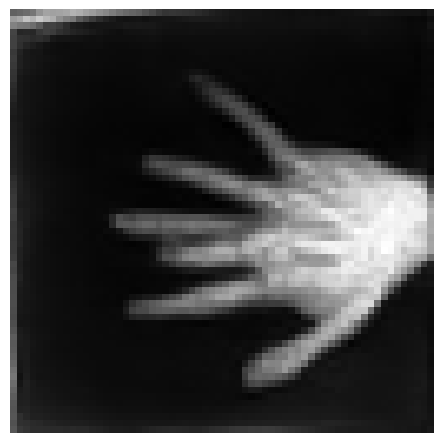

In [15]:
model.eval()
noise = torch.randn((1, 1, 64, 64)).to(device)

backward_process(model, noise)

# Experiment: Use DDPM to denoise images (Our approach)

## Helper functions

In [12]:
# utility: convert data type (numpy <-> torch tensor)
def to_np(x):
    return x.detach().cpu().numpy()

def to_torch(x):
    return torch.from_numpy(x).to(device).type(torch.float32)

# calculate PSNR per batch
def psnr_batch(img_a_batch, img_b_batch):
    assert img_a_batch.shape == img_b_batch.shape
    
    psnr_sum = 0
    for i in range(img_a_batch.shape[0]):
        psnr_sum += psnr(img_a_batch[i], img_b_batch[i])
        
    return psnr_sum

# calculate SSIM per batch
def ssim_batch(img_a_batch, img_b_batch):
    assert img_a_batch.shape == img_b_batch.shape

    ssim_sum = 0
    for i in range(img_a_batch.shape[0]):
        ssim_sum += ssim(img_a_batch[i], img_b_batch[i], data_range=1.0, channel_axis=0)
    
    return ssim_sum

# calculate LPIPS per batch
def lpips_batch(img_a_batch, img_b_batch, lpips_model):
    assert img_a_batch.shape == img_b_batch.shape

    lpips_sum = lpips_model(img_a_batch, img_b_batch)
    lpips_sum = torch.sum(lpips_sum).item()

    return lpips_sum

In [13]:
## self-defined sample function for de-noising (de-noise from t_begin)
def backward_process_denoise(model, noise, t_begin):
    with torch.no_grad():
        x = noise
        for t in range(t_begin, -1, -1):
            t_tensor = torch.full((1,), t, device=device, dtype=torch.float32)
            noise_pred = model(x, timesteps=t_tensor)
            
            # x = sqrt_recip_alphas[t] * (x - betas[t] * noise_pred / sqrt_one_minus_alphas_bar[t])
            # if t > 0:
            #     x = x + sigmas[t] * torch.randn_like(x)
            x, _ = scheduler.step(noise_pred, t, x)

    return x

## Sampling for whole validation set

In [53]:
# running DDPM sampling process from a certain timestep (t_begin) for whole validation set
def sample_all_val_images(model, t_begin, noise_type="gaussian"):
    print(f"Sampling t_begin = {t_begin}")

    # initialize
    images_all = 0
    psnr_noisy_all = 0
    ssim_noisy_all = 0
    lpips_noisy_all = 0
    psnr_denoise_all = 0
    ssim_denoise_all = 0
    lpips_denoise_all = 0

    # setup LPIPS model
    lpips_model = lpips.LPIPS(net='alex').to(device)
    lpips_model.eval()

    img_dict = {}

    # enumerate whole validation set
    for i, batch in enumerate(tqdm(val_loader)):
        # load images from validation loader
        images = batch["image"]
        images_all += images.shape[0]
        if i == 0:
            img_dict["original"] = to_np(images)

        # generate noisy images & calculate metrics of noisy images
        images_noisy = random_noise(images, mode=noise_type)
        noisy_input = to_torch(images_noisy)
        psnr_noisy_all += psnr_batch(to_np(images), to_np(noisy_input))
        ssim_noisy_all += ssim_batch(to_np(images), to_np(noisy_input))
        lpips_noisy_all += lpips_batch(images.to(device), noisy_input, lpips_model)
        if i == 0:
            img_dict["noisy"] = to_np(noisy_input)

        # run DDPM sampling process (from timestep = t_begin)
        denoise_output = backward_process_denoise(model, noisy_input, t_begin)
        denoise_output = torch.clamp(denoise_output, min=0.0, max=1.0)
        if i == 0:
            img_dict["denoise"] = to_np(denoise_output)
        
        # calculate metrics of denoised images
        psnr_denoise_all += psnr_batch(to_np(images), to_np(denoise_output))
        ssim_denoise_all += ssim_batch(to_np(images), to_np(denoise_output))
        lpips_denoise_all += lpips_batch(images.to(device), denoise_output, lpips_model)

    # keep tracking metrics
    psnr_noisy_avg = psnr_noisy_all / images_all
    ssim_noisy_avg = ssim_noisy_all / images_all
    lpips_noisy_avg = lpips_noisy_all / images_all
    psnr_denoise_avg = psnr_denoise_all / images_all
    ssim_denoise_avg = ssim_denoise_all / images_all
    lpips_denoise_avg = lpips_denoise_all / images_all

    # print out results
    print("       noisy  denoise")
    print(f" PSNR: {psnr_noisy_avg:.2f}  {psnr_denoise_avg:.2f}")
    print(f" SSIM: {ssim_noisy_avg:.3f}  {ssim_denoise_avg:.3f}")
    print(f"LPIPS: {lpips_noisy_avg:.3f}  {lpips_denoise_avg:.3f}")

    return psnr_denoise_avg, ssim_denoise_avg, lpips_denoise_avg, img_dict

In [60]:
# run sampling across timestpes
denoise_timesteps = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]  # modify for different t_begin
psnr_all = []
ssim_all = []
lpips_all = []
img_dict_all = {}

# modify the following lines to select the noise type
noise_type = "gaussian"
# noise_type = "s&p"

for t_begin in denoise_timesteps:
    psnr_i, ssim_i, lpips_i, img_dict = sample_all_val_images(model, t_begin, noise_type)
    psnr_all.append(psnr_i)
    ssim_all.append(ssim_i)
    lpips_all.append(lpips_i)
    img_dict_all[t_begin] = img_dict

Sampling t_begin = 1
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/u8518646/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/u8518646/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/u8518646/.local/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


100%|██████████| 2/2 [00:06<00:00,  3.48s/it]


       noisy  denoise
 PSNR: 16.95  17.81
 SSIM: 0.568  0.584
LPIPS: 0.590  0.538
Sampling t_begin = 5
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/u8518646/.local/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


...

       noisy  denoise
 PSNR: 16.96  23.59
 SSIM: 0.570  0.788
LPIPS: 0.588  0.041
Sampling t_begin = 90
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/u8518646/.local/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


100%|██████████| 2/2 [04:24<00:00, 132.28s/it]


       noisy  denoise
 PSNR: 16.94  23.13
 SSIM: 0.566  0.778
LPIPS: 0.592  0.045
Sampling t_begin = 100
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/u8518646/.local/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


100%|██████████| 2/2 [04:53<00:00, 146.76s/it]

       noisy  denoise
 PSNR: 16.98  22.67
 SSIM: 0.570  0.767
LPIPS: 0.588  0.048


## Visualize results

In [50]:
def plot_metric(denoise_timesteps, metric_name, metric_all, noisy_value, save_fig=False):
    x_ticks = range(len(denoise_timesteps))

    plt.plot(x_ticks, metric_all, label='denoise image')
    plt.plot(x_ticks, [noisy_value] * len(denoise_timesteps), label='noisy image')
    plt.xticks(ticks=x_ticks, labels=denoise_timesteps)
    
    plt.title(metric_name)
    plt.xlabel('sampling timesteps')
    plt.ylabel(metric_name)
    
    plt.legend()
    if save_fig:
        plt.savefig(metric_name+'.png')
    
    plt.show()

In [51]:
# plot the evaluation results across different timesteps (remember to modify the value of noisy image)
plot_metric(denoise_timesteps, 'PSNR', psnr_all, 21.44, save_fig=True)

NameError: name 'denoise_timesteps' is not defined

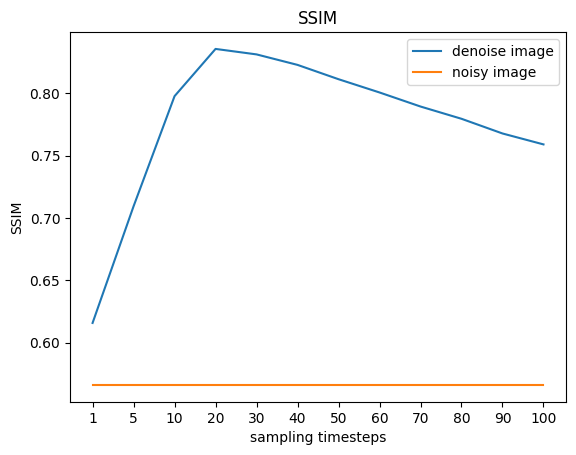

In [58]:
plot_metric(denoise_timesteps, 'SSIM', ssim_all, 0.566, save_fig=True)

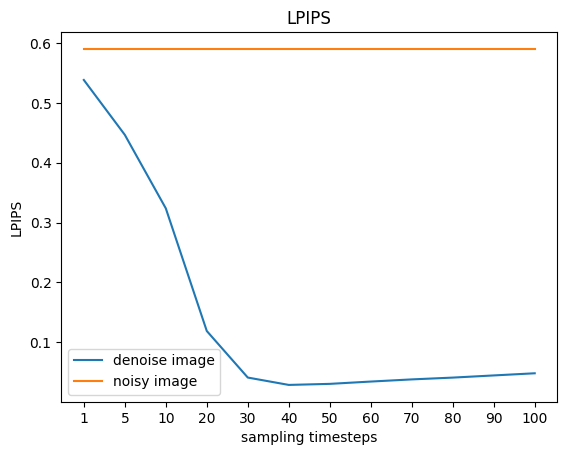

In [61]:
plot_metric(denoise_timesteps, 'LPIPS', lpips_all, 0.590, save_fig=True)

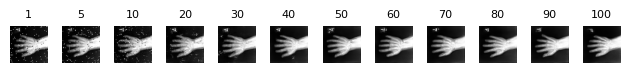

<Figure size 640x480 with 0 Axes>

In [24]:
# show figure from different timesteps in a subplot
FIG_ID = 0  # modify for different figure

fig, axes = plt.subplots(nrows=1, ncols=len(denoise_timesteps))

for i, key in enumerate(img_dict_all):
    ax = axes[i]
    ax.imshow(img_dict_all[key]['denoise'][FIG_ID].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(key, fontsize=8)
    
plt.tight_layout()
plt.show()
plt.clf()

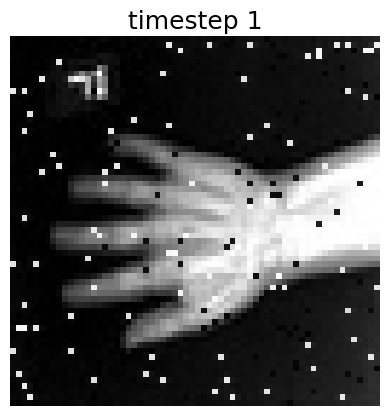

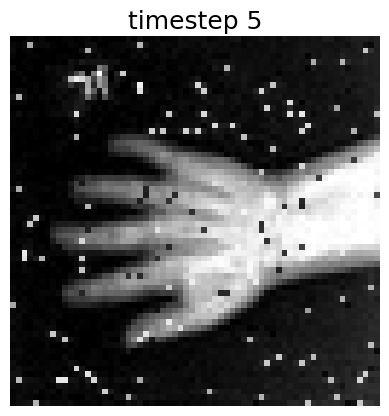

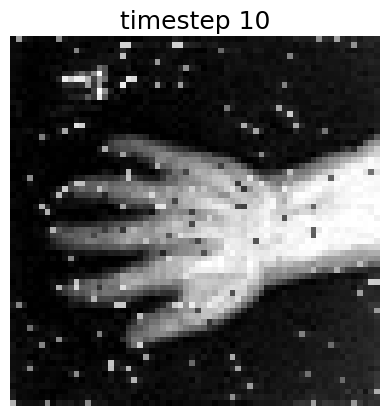

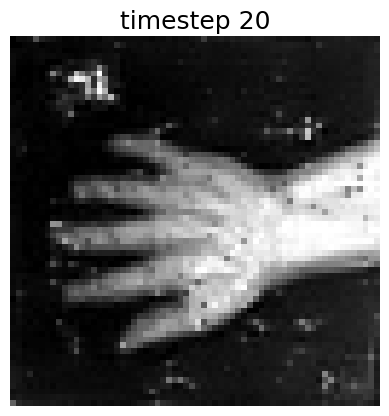

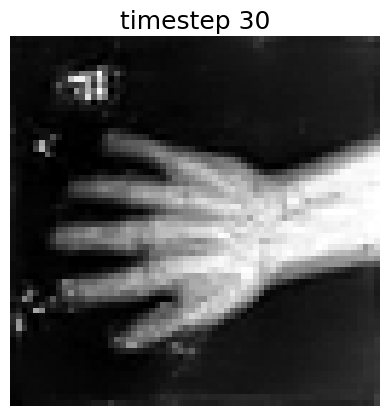

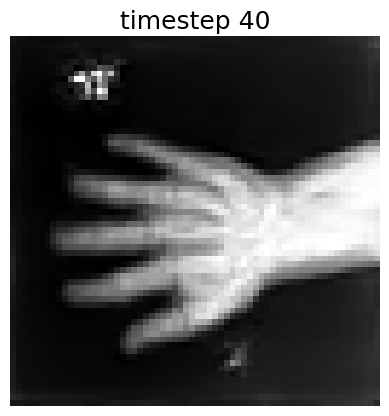

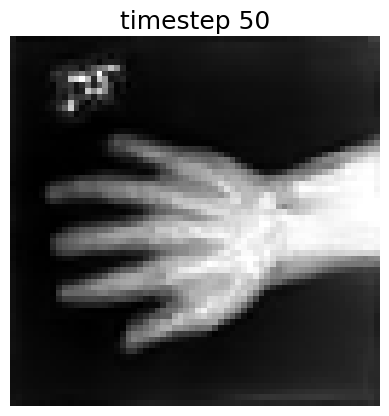

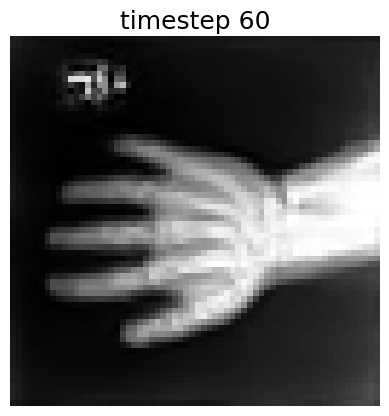

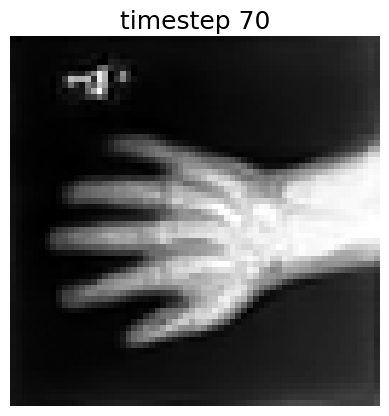

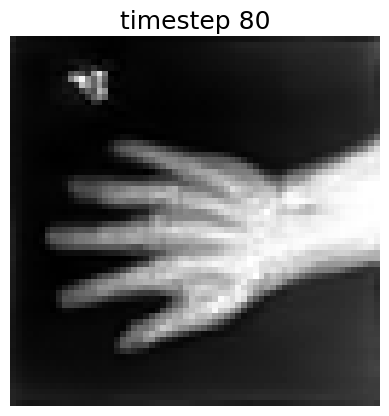

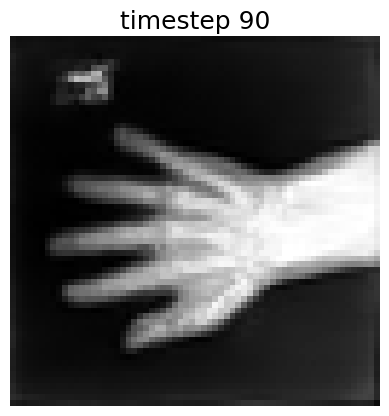

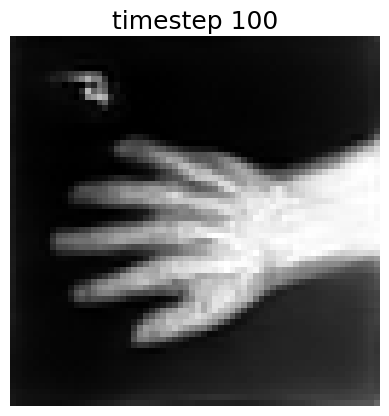

In [25]:
# save figure from different timesteps (independent files)
FIG_ID = 0  # modify for different figure
save_path = "./diff_timestep_image"

for i, key in enumerate(img_dict_all):
    plt.imshow(img_dict_all[key]['denoise'][FIG_ID].squeeze(), cmap='gray')
    # plt.tight_layout()
    plt.axis("off")
    plt.title(f"timestep {key}", fontsize=18)
    plt.savefig(os.path.join(save_path, f"timestep_{key}.png"))
    plt.show()

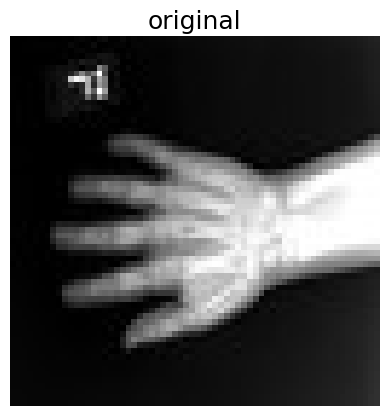

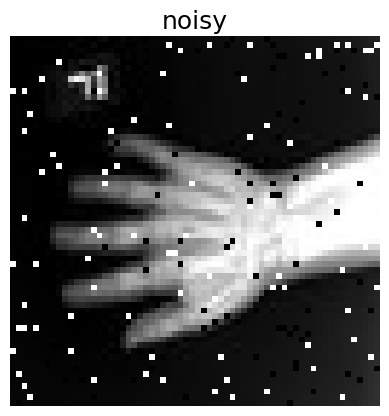

In [32]:
# save original and noisy figure
FIG_ID = 0  # modify for different figure
save_path = "./diff_timestep_image"

# obtain the first image in the dictionary
first_img = next(iter(img_dict_all.values()))

# save original figure
plt.imshow(first_img['original'][FIG_ID].squeeze(), cmap='gray')
plt.axis("off")
plt.title("original", fontsize=18)
plt.savefig(os.path.join(save_path, "original.png"))
plt.show()

# save noisy figure
plt.imshow(first_img['noisy'][FIG_ID].squeeze(), cmap='gray')
plt.axis("off")
plt.title("noisy", fontsize=18)
plt.savefig(os.path.join(save_path, "noisy.png"))
plt.show()

### Cleanup data directory

Remove directory if a temporary was used.

In [13]:
if directory is None:
    shutil.rmtree(root_dir)